In [20]:
# ============================================================
# 1. PROJECT SETUP + INTERNAL IMPORTS
# ============================================================

from pathlib import Path
import sys
import logging
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    log_loss,
    brier_score_loss,
)

# ------------------------------------------------------------
# Locate project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "pyproject.toml").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate project root containing pyproject.toml.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
# ------------------------------------------------------------
# Internal project imports
# ------------------------------------------------------------

from credit_risk.utils.config import (
    read_config,
    create_path,
)

from credit_risk.data.readers import (
    iter_performance,
    read_origination,
)

from credit_risk.data.transformers import (
    transform_performance,
    transform_origination,
)

from credit_risk.data.validation import (
    validate_performance,
    validate_origination,
)

print("Internal imports loaded successfully.")

Project root: c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk
Internal imports loaded successfully.


In [21]:
# ============================================================
# 2. LOAD PROJECT CONFIGURATION
# ============================================================

config = read_config(PROJECT_ROOT)

print("Configuration loaded successfully.")

print(
    "Modelling approach:",
    config["parameters"]["modelling_approach"],
)

Configuration loaded successfully.
Modelling approach: behavioral


In [22]:
# ============================================================
# 3. MODEL / DATA CONFIGURATION
# ============================================================

data_config = config["parameters"]["data"]
modelling_config = config["parameters"]["modelling"]

provider = data_config["data_provider"]

target = config["parameters"]["target"]['name']

feature_config = modelling_config["features"]

numerical_features = feature_config["numerical_features"]
categorical_features = feature_config["categorical_features"]

X_columns = numerical_features + categorical_features

print("Provider:", provider)
print("Target:", target)
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(X_columns))

Provider: freddie_mac
Target: future_90dpd_12m
Numerical features: 46
Categorical features: 12
Total features: 58


In [23]:
# ============================================================
# 4. SPARK SESSION
# ============================================================


from credit_risk.utils.spark import create_spark_session

spark = create_spark_session(config)

spark.sparkContext.setLogLevel("WARN")



In [24]:
# ============================================================
# 3. LOAD MODELLING DATA
# ============================================================

from credit_risk.modelling.data_spark import load_modelling_vintage_spark

train_vintages = sorted(config["parameters"]["modelling"]["vintages_train"])

val_vintages = sorted(config["parameters"]["modelling"]["vintages_test"])

# OOT is 2022 based on our current setup
oot_vintages = [2022]

print("Train vintages:", train_vintages)
print("Validation vintages:", val_vintages)
print("OOT vintages:", oot_vintages)

train_df = load_modelling_vintage_spark(
    spark,
    config,
    train_vintages,
)

val_df = load_modelling_vintage_spark(
    spark,
    config,
    val_vintages,
)

oot_df = load_modelling_vintage_spark(
    spark,
    config,
    oot_vintages,
)

print("\nLoaded successfully.")

Train vintages: [2015, 2016, 2017, 2018, 2019, 2020]
Validation vintages: [2021]
OOT vintages: [2022]

Loaded successfully.


In [25]:
# ============================================================
# 4. DATA SANITY CHECK
# ============================================================

for name, df in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("OOT", oot_df),
]:
    print(f"\n{name}")
    print("-" * 50)
    print("Columns:", len(df.columns))
    print("Rows:", f"{df.count():,}")

    if "vintage" in df.columns:
        print(
            "Vintages:",
            [
                row["vintage"]
                for row in (
                    df.select("vintage").distinct().orderBy("vintage").collect()
                )
            ],
        )


TRAIN
--------------------------------------------------
Columns: 82
Rows: 21,166,280
Vintages: [2015, 2016, 2017, 2018, 2019, 2020]

VAL
--------------------------------------------------
Columns: 82
Rows: 7,846,853
Vintages: [2021]

OOT
--------------------------------------------------
Columns: 82
Rows: 3,050,733
Vintages: [2022]


In [26]:
# ============================================================
# 5. TARGET + FEATURE CONFIG
# ============================================================

target = config["parameters"]["target"]["name"]

feature_config = config["parameters"]["modelling"]["features"]

numerical_features = feature_config["numerical_features"]
categorical_features = feature_config["categorical_features"]

all_features = numerical_features + categorical_features

print("Target:", target)
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total configured features:", len(all_features))

Target: future_90dpd_12m
Numerical features: 46
Categorical features: 12
Total configured features: 58


In [27]:
# ============================================================
# 6. VERIFY TEMPORAL SPLIT
# ============================================================

for name, df in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("OOT", oot_df),
]:

    print(f"\n{name}")
    print("-" * 50)

    (df.groupBy("vintage").count().orderBy("vintage").show())


TRAIN
--------------------------------------------------
+-------+-------+
|vintage|  count|
+-------+-------+
|   2015|2741047|
|   2016|3233622|
|   2017|2623879|
|   2018|2371786|
|   2019|3063859|
|   2020|7132087|
+-------+-------+


VAL
--------------------------------------------------
+-------+-------+
|vintage|  count|
+-------+-------+
|   2021|7846853|
+-------+-------+


OOT
--------------------------------------------------
+-------+-------+
|vintage|  count|
+-------+-------+
|   2022|3050733|
+-------+-------+



In [28]:
# ============================================================
# 7. EVENT RATE BY VINTAGE
# ============================================================

for name, df in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("OOT", oot_df),
]:

    stats = df.agg(
        F.count("*").alias("population"),
        F.sum(F.col(target)).alias("events"),
        F.avg(F.col(target)).alias("event_rate"),
    ).collect()[0]

    print(
        f"{name:<6} "
        f"population={stats['population']:,} "
        f"events={int(stats['events']):,} "
        f"event_rate={stats['event_rate']:.4%}"
    )

TRAIN  population=21,166,280 events=203,051 event_rate=0.9593%
VAL    population=7,846,853 events=43,262 event_rate=0.5513%
OOT    population=3,050,733 events=32,352 event_rate=1.0605%


In [29]:
from credit_risk.modelling.artifacts_spark import load_spark_model_artifacts

model, preprocessor = load_spark_model_artifacts(config)

In [30]:
# ============================================================
# PREDICTIONS FOR MONTHLY EVALUATION
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Transform the datasets using the fitted preprocessing pipeline
train_prepared = preprocessor.transform(train_df)
val_prepared = preprocessor.transform(val_df)
oot_prepared = preprocessor.transform(oot_df)

# Model predictions
train_predictions = model.transform(train_prepared).select(
    "loan_id",
    "vintage",
    target,
    "probability",
    "prediction",
)

val_predictions = model.transform(val_prepared).select(
    "loan_id",
    "vintage",
    target,
    "probability",
    "prediction",
)

oot_predictions = model.transform(oot_prepared).select(
    "loan_id",
    "vintage",
    target,
    "probability",
    "prediction",
)

print("Predictions generated.")

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\functions.py:777: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\typehints.py:60: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Predictions generated.


In [31]:
# ============================================================
# INSPECT TEMPORAL COLUMNS
# ============================================================

print("Available columns:")
for c in oot_predictions.columns:
    print(c)

Available columns:
loan_id
vintage
future_90dpd_12m
probability
prediction


In [32]:
# ============================================================
# GENERATE OOT PREDICTIONS
# ============================================================

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

oot_predictions = model.transform(preprocessor.transform(oot_df)).select(
    "loan_id",
    "period",
    F.col(target).cast("double").alias("label"),
    vector_to_array("probability").getItem(1).alias("pd"),
)

print(f"OOT prediction rows: {oot_predictions.count():,}")

oot_predictions.select(
    "loan_id",
    "period",
    "label",
    "pd",
).show(10, truncate=False)

OOT prediction rows: 3,050,733
+------------+------+-----+--------------------+
|loan_id     |period|label|pd                  |
+------------+------+-----+--------------------+
|F22Q10000383|631   |0.0  |0.018900852650403976|
|F22Q10000392|637   |0.0  |0.10302738100290298 |
|F22Q10000498|637   |0.0  |0.016949638724327087|
|F22Q10000914|637   |0.0  |0.003086280543357134|
|F22Q10001124|637   |0.0  |0.03185616433620453 |
|F22Q10001251|637   |0.0  |0.03253333270549774 |
|F22Q10001315|631   |0.0  |0.010054271668195724|
|F22Q10001334|631   |0.0  |0.10344012826681137 |
|F22Q10001662|637   |0.0  |0.03952914848923683 |
|F22Q10001745|638   |0.0  |0.003177776699885726|
+------------+------+-----+--------------------+
only showing top 10 rows


In [33]:
# ============================================================
# MONTHLY EVENT RATE — OOT
# ============================================================

monthly_event_rate = (
    oot_predictions.groupBy("period")
    .agg(
        F.count("*").alias("population"),
        F.sum("label").alias("events"),
        F.avg("label").alias("event_rate"),
    )
    .orderBy("period")
)

monthly_event_rate.show(100, truncate=False)

+------+----------+------+--------------------+
|period|population|events|event_rate          |
+------+----------+------+--------------------+
|630   |754       |3.0   |0.003978779840848806|
|631   |189484    |1490.0|0.007863460767136012|
|632   |182487    |1497.0|0.008203324072399678|
|633   |196077    |1769.0|0.00902196586035078 |
|634   |157664    |1627.0|0.010319413436168054|
|635   |137248    |1519.0|0.01106755653998601 |
|636   |137349    |1479.0|0.010768189065810454|
|637   |301693    |2873.0|0.009522925623067158|
|638   |295079    |2823.0|0.00956692953412476 |
|639   |288253    |2875.0|0.009973877114895596|
|640   |234857    |2512.0|0.01069587025296244 |
|641   |199654    |2370.0|0.011870536027327277|
|642   |200886    |2388.0|0.011887339087840865|
|643   |113465    |1485.0|0.013087736306349976|
|644   |112953    |1460.0|0.012925730170956062|
|645   |93436     |1259.0|0.013474463804101203|
|646   |78272     |1074.0|0.013721381847914963|
|647   |63733     |874.0 |0.013713460844

In [34]:
# ============================================================
# CHECK PERIOD RANGE / DISTRIBUTION
# ============================================================

oot_predictions.select(
    F.min("period").alias("min_period"),
    F.max("period").alias("max_period"),
    F.countDistinct("period").alias("distinct_periods"),
).show()

oot_predictions.select("period").distinct().orderBy("period").show(100, truncate=False)

+----------+----------+----------------+
|min_period|max_period|distinct_periods|
+----------+----------+----------------+
|       630|       662|              33|
+----------+----------+----------------+

+------+
|period|
+------+
|630   |
|631   |
|632   |
|633   |
|634   |
|635   |
|636   |
|637   |
|638   |
|639   |
|640   |
|641   |
|642   |
|643   |
|644   |
|645   |
|646   |
|647   |
|648   |
|649   |
|650   |
|651   |
|652   |
|653   |
|654   |
|655   |
|656   |
|657   |
|658   |
|659   |
|660   |
|661   |
|662   |
+------+



In [35]:
# ============================================================
# TARGET AVAILABILITY BY PERIOD
# ============================================================

oot_predictions.groupBy("period").agg(
    F.count("*").alias("population"),
    F.sum("label").alias("events"),
    F.avg("label").alias("event_rate"),
).orderBy("period").show(
    100,
    truncate=False,
)

+------+----------+------+--------------------+
|period|population|events|event_rate          |
+------+----------+------+--------------------+
|630   |754       |3.0   |0.003978779840848806|
|631   |189484    |1490.0|0.007863460767136012|
|632   |182487    |1497.0|0.008203324072399678|
|633   |196077    |1769.0|0.00902196586035078 |
|634   |157664    |1627.0|0.010319413436168054|
|635   |137248    |1519.0|0.01106755653998601 |
|636   |137349    |1479.0|0.010768189065810454|
|637   |301693    |2873.0|0.009522925623067158|
|638   |295079    |2823.0|0.00956692953412476 |
|639   |288253    |2875.0|0.009973877114895596|
|640   |234857    |2512.0|0.01069587025296244 |
|641   |199654    |2370.0|0.011870536027327277|
|642   |200886    |2388.0|0.011887339087840865|
|643   |113465    |1485.0|0.013087736306349976|
|644   |112953    |1460.0|0.012925730170956062|
|645   |93436     |1259.0|0.013474463804101203|
|646   |78272     |1074.0|0.013721381847914963|
|647   |63733     |874.0 |0.013713460844

In [38]:
# ============================================================
# MONTHLY PR-AUC — OOT
# ============================================================

from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Collect predictions ONCE
# ------------------------------------------------------------

print("Collecting OOT predictions once...")

oot_pd = oot_predictions.select(
    "period",
    "label",
    "pd",
).toPandas()

print(f"Collected {len(oot_pd):,} observations.")

# ------------------------------------------------------------
# 2. Calculate PR-AUC month by month locally
# ------------------------------------------------------------

monthly_results = []

for month, month_pd in tqdm(
    oot_pd.groupby("period", sort=True),
    desc="Calculating monthly PR-AUC",
    unit="month",
):

    labels = month_pd["label"].to_numpy()
    scores = month_pd["pd"].to_numpy()

    if len(np.unique(labels)) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(
            labels,
            scores,
        )

    monthly_results.append(
        {
            "period": month,
            "population": len(month_pd),
            "events": int(labels.sum()),
            "event_rate": labels.mean(),
            "pr_auc": pr_auc,
        }
    )

# ------------------------------------------------------------
# 3. Final result
# ------------------------------------------------------------

monthly_pr_auc = (
    pd.DataFrame(monthly_results).sort_values("period").reset_index(drop=True)
)

monthly_pr_auc

c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Collected 3,050,733 observations.


Calculating monthly PR-AUC: 100%|██████████| 33/33 [00:00<00:00, 39.78month/s]


,period,population,events,event_rate,pr_auc
0,630,754,3,0.003979,0.245726
1,631,189484,1490,0.007863,0.113159
2,632,182487,1497,0.008203,0.148876
3,633,196077,1769,0.009022,0.151553
4,634,157664,1627,0.010319,0.149151
5,635,137248,1519,0.011068,0.166310
6,636,137349,1479,0.010768,0.162346
7,637,301693,2873,0.009523,0.164416
8,638,295079,2823,0.009567,0.176067
9,639,288253,2875,0.009974,0.161264


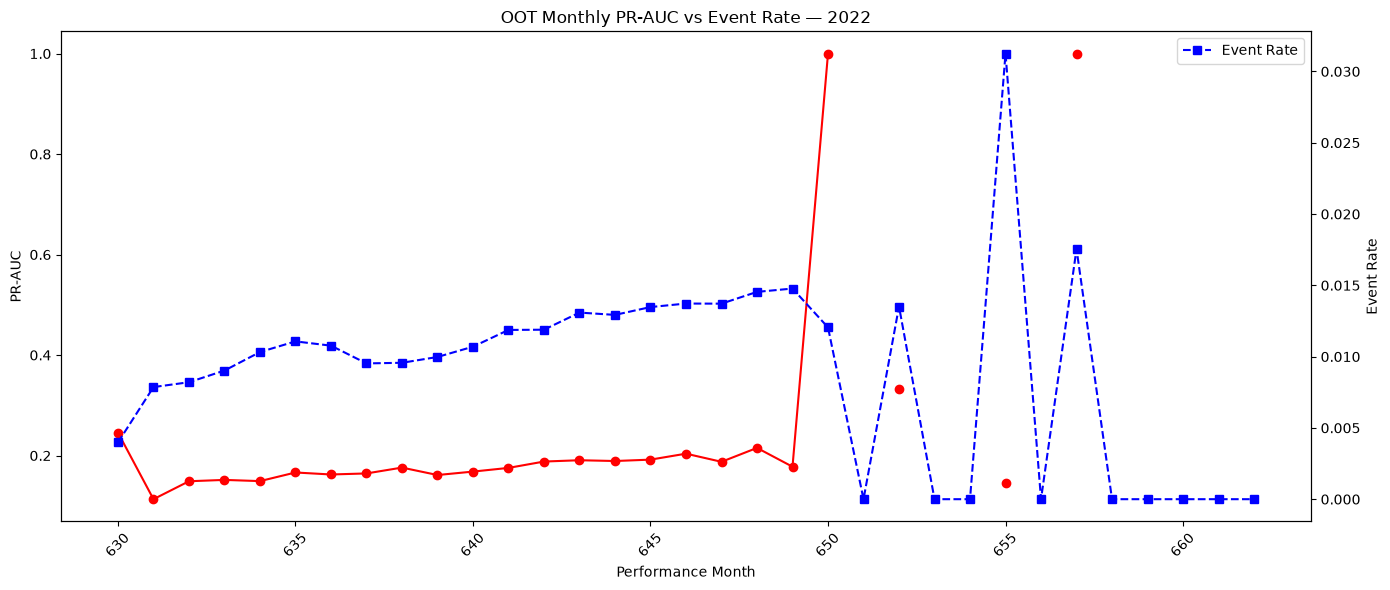

In [43]:
# ============================================================
# MONTHLY PR-AUC
# ============================================================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    monthly_pr_auc["period"],
    monthly_pr_auc["pr_auc"],
    marker="o",
    color="red",
    label="PR-AUC",
)

ax1.set_xlabel("Performance Month")
ax1.set_ylabel("PR-AUC")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_pr_auc["period"],
    monthly_pr_auc["event_rate"],
    marker="s",
    linestyle="--",
    color="blue",
    label="Event Rate",
)

ax2.set_ylabel("Event Rate")
plt.legend()
plt.title("OOT Monthly PR-AUC vs Event Rate — 2022")
plt.tight_layout()
plt.show()